In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
jeep_df = pd.read_csv("export_jeep_pool.csv")
jeep_df

,id,max_passengers,state,distance,speed,passenger_served,current_passengers,arrive_times,embark_times
0,0,20,1,1,0.0025,300,NaN,10336|26009|28810|31611|33607|35288|36969|3956...,9496|23209|26010|28811|31612|33608|35289|37881...
1,1,20,0,0,0.0025,300,NaN,13898|26366|29167|31968|33821|35502|37183|4307...,13058|23566|26367|29168|31969|33822|35503|4139...
2,2,20,1,1,0.0025,300,NaN,24419|27220|30021|32653|34334|36015|37696|4086...,21619|24420|27221|30022|32654|34335|36016|3918...
3,3,20,0,0,0.0025,300,NaN,24425|27226|30027|32656|34337|36018|37699|4402...,21625|24426|27227|30028|32657|34338|36019|4284...
4,4,20,1,1,0.0025,300,NaN,24705|27506|30307|32824|34505|36186|37867|4183...,21905|24706|27507|30308|32825|34506|36187|4015...
5,5,20,0,0,0.0025,300,NaN,24703|27504|30305|32823|34504|36185|37866|4540...,21903|24704|27505|30306|32824|34505|36186|4435...
6,6,20,0,0,0.0025,297,4369|4370|4375|4376|4377|4378|4379|4380|4381|4...,24960|27761|30562|32977|34658|36339|38020|4287...,22160|24961|27762|30563|32978|34659|36340|4119...
7,7,20,0,0,0.0025,300,NaN,24876|27677|30478|32927|34608|36289|37970|4893...,22076|24877|27678|30479|32928|34609|36290|4788...
8,8,20,0,0,0.0025,280,NaN,25223|28024|30825|33135|34816|36497|38202|4380...,22423|25224|28025|30826|33136|34817|36522|4248...
9,9,20,0,0,0.0025,300,NaN,25083|27884|30685|33051|34732|36413|38094|5149...,22283|25084|27885|30686|33052|34733|36414|5044...


In [3]:
jeep_df["arrive_times"] = jeep_df["arrive_times"].str.split('|').apply(lambda lst: list(map(int, lst)))

jeep_df["arrive_times"]

0     [10336, 26009, 28810, 31611, 33607, 35288, 369...
1     [13898, 26366, 29167, 31968, 33821, 35502, 371...
2     [24419, 27220, 30021, 32653, 34334, 36015, 376...
3     [24425, 27226, 30027, 32656, 34337, 36018, 376...
4     [24705, 27506, 30307, 32824, 34505, 36186, 378...
5     [24703, 27504, 30305, 32823, 34504, 36185, 378...
6     [24960, 27761, 30562, 32977, 34658, 36339, 380...
7     [24876, 27677, 30478, 32927, 34608, 36289, 379...
8     [25223, 28024, 30825, 33135, 34816, 36497, 382...
9     [25083, 27884, 30685, 33051, 34732, 36413, 380...
10    [25520, 28321, 31122, 33313, 34994, 36675, 394...
11    [25322, 28123, 30924, 33195, 34876, 36557, 382...
12    [25820, 28621, 31422, 33493, 35174, 36855, 402...
13    [25607, 28408, 31209, 33366, 35047, 36728, 384...
14    [26125, 28926, 31727, 33676, 35357, 37038, 415...
Name: arrive_times, dtype: object

In [4]:
jeep_df["embark_times"] = jeep_df["embark_times"].str.split('|').apply(lambda lst: list(map(int, lst)))

jeep_df["embark_times"]

0     [9496, 23209, 26010, 28811, 31612, 33608, 3528...
1     [13058, 23566, 26367, 29168, 31969, 33822, 355...
2     [21619, 24420, 27221, 30022, 32654, 34335, 360...
3     [21625, 24426, 27227, 30028, 32657, 34338, 360...
4     [21905, 24706, 27507, 30308, 32825, 34506, 361...
5     [21903, 24704, 27505, 30306, 32824, 34505, 361...
6     [22160, 24961, 27762, 30563, 32978, 34659, 363...
7     [22076, 24877, 27678, 30479, 32928, 34609, 362...
8     [22423, 25224, 28025, 30826, 33136, 34817, 365...
9     [22283, 25084, 27885, 30686, 33052, 34733, 364...
10    [22720, 25521, 28322, 31123, 33314, 34995, 377...
11    [22522, 25323, 28124, 30925, 33196, 34877, 365...
12    [23020, 25821, 28622, 31423, 33494, 35175, 386...
13    [22807, 25608, 28409, 31210, 33367, 35048, 367...
14    [23325, 26126, 28927, 31728, 33677, 35358, 399...
Name: embark_times, dtype: object

In [5]:
jeep_df["queue_start_times"] = jeep_df["arrive_times"].apply(
    lambda times: [0] + times[:-1]
)



In [6]:
jeep_df["queue_wait_times"] = jeep_df.apply(
    lambda row: [eb - qs  for qs, eb in zip(row["queue_start_times"], row["embark_times"])],
    axis=1
)

In [7]:
jeep_df[["embark_times", "arrive_times", "queue_start_times", "queue_wait_times"]].head()


,embark_times,arrive_times,queue_start_times,queue_wait_times
0,"[9496, 23209, 26010, 28811, 31612, 33608, 3528...","[10336, 26009, 28810, 31611, 33607, 35288, 369...","[0, 10336, 26009, 28810, 31611, 33607, 35288, ...","[9496, 12873, 1, 1, 1, 1, 1, 912, 17715, 2202,..."
1,"[13058, 23566, 26367, 29168, 31969, 33822, 355...","[13898, 26366, 29167, 31968, 33821, 35502, 371...","[0, 13898, 26366, 29167, 31968, 33821, 35502, ...","[13058, 9668, 1, 1, 1, 1, 1, 4215, 6671, 11737..."
2,"[21619, 24420, 27221, 30022, 32654, 34335, 360...","[24419, 27220, 30021, 32653, 34334, 36015, 376...","[0, 24419, 27220, 30021, 32653, 34334, 36015, ...","[21619, 1, 1, 1, 1, 1, 1, 1492, 18852, 1, 1, 1..."
3,"[21625, 24426, 27227, 30028, 32657, 34338, 360...","[24425, 27226, 30027, 32656, 34337, 36018, 376...","[0, 24425, 27226, 30027, 32656, 34337, 36018, ...","[21625, 1, 1, 1, 1, 1, 1, 5142, 8155, 9522, 1,..."
4,"[21905, 24706, 27507, 30308, 32825, 34506, 361...","[24705, 27506, 30307, 32824, 34505, 36186, 378...","[0, 24705, 27506, 30307, 32824, 34505, 36186, ...","[21905, 1, 1, 1, 1, 1, 1, 2291, 19454, 1, 1, 1..."


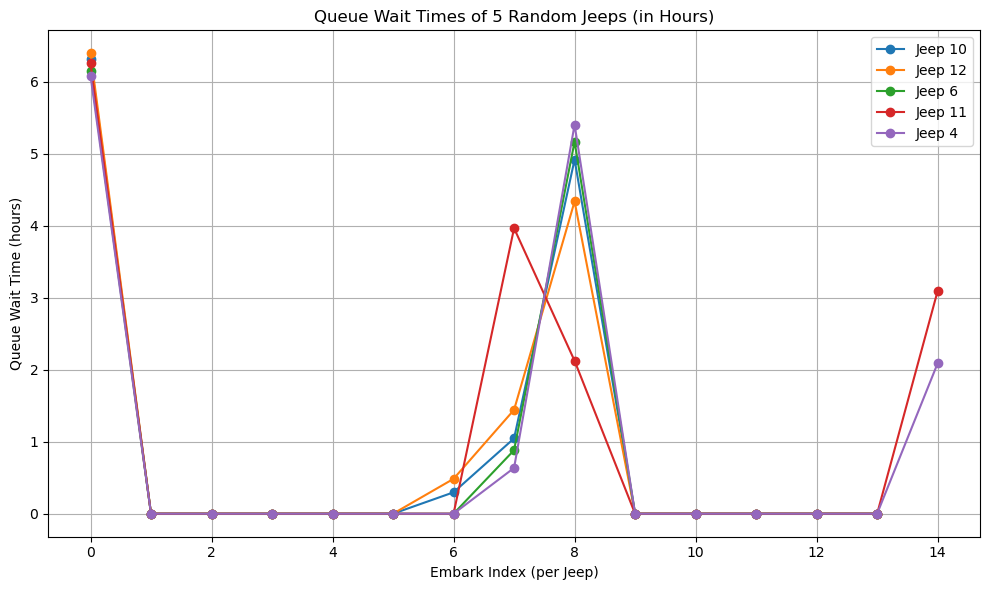

In [8]:
import random

# Randomly select 5 jeep indices
random_indices = random.sample(range(len(jeep_df)), 5)

# Plot each selected jeep's queue wait times (converted to hours)
plt.figure(figsize=(10, 6))
for idx in random_indices:
    wait_times_sec = jeep_df.loc[idx, "queue_wait_times"]
    wait_times_hr = [t / 3600 for t in wait_times_sec]  # Convert to hours
    plt.plot(range(len(wait_times_hr)), wait_times_hr, marker='o', label=f"Jeep {idx}")

plt.xlabel("Embark Index (per Jeep)")
plt.ylabel("Queue Wait Time (hours)")
plt.title("Queue Wait Times of 5 Random Jeeps (in Hours)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
jeep_df["embark_hours"] = jeep_df["embark_times"].apply(
    lambda times: [round(int(t) / 3600, 2) for t in times]
)

jeep_df["embark_hours"]

0     [2.64, 6.45, 7.22, 8.0, 8.78, 9.34, 9.8, 10.52...
1     [3.63, 6.55, 7.32, 8.1, 8.88, 9.39, 9.86, 11.5...
2     [6.01, 6.78, 7.56, 8.34, 9.07, 9.54, 10.0, 10....
3     [6.01, 6.79, 7.56, 8.34, 9.07, 9.54, 10.01, 11...
4     [6.08, 6.86, 7.64, 8.42, 9.12, 9.59, 10.05, 11...
5     [6.08, 6.86, 7.64, 8.42, 9.12, 9.58, 10.05, 12...
6     [6.16, 6.93, 7.71, 8.49, 9.16, 9.63, 10.09, 11...
7     [6.13, 6.91, 7.69, 8.47, 9.15, 9.61, 10.08, 13...
8     [6.23, 7.01, 7.78, 8.56, 9.2, 9.67, 10.14, 11....
9     [6.19, 6.97, 7.75, 8.52, 9.18, 9.65, 10.12, 14...
10    [6.31, 7.09, 7.87, 8.65, 9.25, 9.72, 10.48, 12...
11    [6.26, 7.03, 7.81, 8.59, 9.22, 9.69, 10.15, 14...
12    [6.39, 7.17, 7.95, 8.73, 9.3, 9.77, 10.72, 12....
13    [6.34, 7.11, 7.89, 8.67, 9.27, 9.74, 10.2, 15....
14    [6.48, 7.26, 8.04, 8.81, 9.35, 9.82, 11.08, 13...
Name: embark_hours, dtype: object

In [10]:
jeep_df["arrive_hours"] = jeep_df["arrive_times"].apply(
    lambda times: [round(int(t) / 3600, 2) for t in times]
)

jeep_df["arrive_hours"]

0     [2.87, 7.22, 8.0, 8.78, 9.34, 9.8, 10.27, 10.9...
1     [3.86, 7.32, 8.1, 8.88, 9.39, 9.86, 10.33, 11....
2     [6.78, 7.56, 8.34, 9.07, 9.54, 10.0, 10.47, 11...
3     [6.78, 7.56, 8.34, 9.07, 9.54, 10.01, 10.47, 1...
4     [6.86, 7.64, 8.42, 9.12, 9.58, 10.05, 10.52, 1...
5     [6.86, 7.64, 8.42, 9.12, 9.58, 10.05, 10.52, 1...
6     [6.93, 7.71, 8.49, 9.16, 9.63, 10.09, 10.56, 1...
7     [6.91, 7.69, 8.47, 9.15, 9.61, 10.08, 10.55, 1...
8     [7.01, 7.78, 8.56, 9.2, 9.67, 10.14, 10.61, 12...
9     [6.97, 7.75, 8.52, 9.18, 9.65, 10.11, 10.58, 1...
10    [7.09, 7.87, 8.64, 9.25, 9.72, 10.19, 10.95, 1...
11    [7.03, 7.81, 8.59, 9.22, 9.69, 10.15, 10.62, 1...
12    [7.17, 7.95, 8.73, 9.3, 9.77, 10.24, 11.19, 12...
13    [7.11, 7.89, 8.67, 9.27, 9.74, 10.2, 10.67, 15...
14    [7.26, 8.04, 8.81, 9.35, 9.82, 10.29, 11.55, 1...
Name: arrive_hours, dtype: object

In [11]:
jeep_df["gross_profit"] = jeep_df["passenger_served"] * 13

jeep_df["gross_profit"]

0     3900
1     3900
2     3900
3     3900
4     3900
5     3900
6     3861
7     3900
8     3640
9     3900
10    3640
11    3900
12    3640
13    3679
14    3640
Name: gross_profit, dtype: int64

In [12]:
route_distance = 5 #change if needed
gas_price = 60
liters_per_km = 0.181818
jeep_df["gas_expense"] = len(jeep_df["embark_times"]) * route_distance * liters_per_km * gas_price

In [13]:
jeep_df["gas_expense"]

0     818.181
1     818.181
2     818.181
3     818.181
4     818.181
5     818.181
6     818.181
7     818.181
8     818.181
9     818.181
10    818.181
11    818.181
12    818.181
13    818.181
14    818.181
Name: gas_expense, dtype: float64

In [14]:
jeep_df["net_profit"] = jeep_df["gross_profit"] - jeep_df["gas_expense"]

In [15]:
jeep_df

,id,max_passengers,state,distance,speed,passenger_served,current_passengers,arrive_times,embark_times,queue_start_times,queue_wait_times,embark_hours,arrive_hours,gross_profit,gas_expense,net_profit
0,0,20,1,1,0.0025,300,NaN,"[10336, 26009, 28810, 31611, 33607, 35288, 369...","[9496, 23209, 26010, 28811, 31612, 33608, 3528...","[0, 10336, 26009, 28810, 31611, 33607, 35288, ...","[9496, 12873, 1, 1, 1, 1, 1, 912, 17715, 2202,...","[2.64, 6.45, 7.22, 8.0, 8.78, 9.34, 9.8, 10.52...","[2.87, 7.22, 8.0, 8.78, 9.34, 9.8, 10.27, 10.9...",3900,818.181,3081.819
1,1,20,0,0,0.0025,300,NaN,"[13898, 26366, 29167, 31968, 33821, 35502, 371...","[13058, 23566, 26367, 29168, 31969, 33822, 355...","[0, 13898, 26366, 29167, 31968, 33821, 35502, ...","[13058, 9668, 1, 1, 1, 1, 1, 4215, 6671, 11737...","[3.63, 6.55, 7.32, 8.1, 8.88, 9.39, 9.86, 11.5...","[3.86, 7.32, 8.1, 8.88, 9.39, 9.86, 10.33, 11....",3900,818.181,3081.819
2,2,20,1,1,0.0025,300,NaN,"[24419, 27220, 30021, 32653, 34334, 36015, 376...","[21619, 24420, 27221, 30022, 32654, 34335, 360...","[0, 24419, 27220, 30021, 32653, 34334, 36015, ...","[21619, 1, 1, 1, 1, 1, 1, 1492, 18852, 1, 1, 1...","[6.01, 6.78, 7.56, 8.34, 9.07, 9.54, 10.0, 10....","[6.78, 7.56, 8.34, 9.07, 9.54, 10.0, 10.47, 11...",3900,818.181,3081.819
3,3,20,0,0,0.0025,300,NaN,"[24425, 27226, 30027, 32656, 34337, 36018, 376...","[21625, 24426, 27227, 30028, 32657, 34338, 360...","[0, 24425, 27226, 30027, 32656, 34337, 36018, ...","[21625, 1, 1, 1, 1, 1, 1, 5142, 8155, 9522, 1,...","[6.01, 6.79, 7.56, 8.34, 9.07, 9.54, 10.01, 11...","[6.78, 7.56, 8.34, 9.07, 9.54, 10.01, 10.47, 1...",3900,818.181,3081.819
4,4,20,1,1,0.0025,300,NaN,"[24705, 27506, 30307, 32824, 34505, 36186, 378...","[21905, 24706, 27507, 30308, 32825, 34506, 361...","[0, 24705, 27506, 30307, 32824, 34505, 36186, ...","[21905, 1, 1, 1, 1, 1, 1, 2291, 19454, 1, 1, 1...","[6.08, 6.86, 7.64, 8.42, 9.12, 9.59, 10.05, 11...","[6.86, 7.64, 8.42, 9.12, 9.58, 10.05, 10.52, 1...",3900,818.181,3081.819
5,5,20,0,0,0.0025,300,NaN,"[24703, 27504, 30305, 32823, 34504, 36185, 378...","[21903, 24704, 27505, 30306, 32824, 34505, 361...","[0, 24703, 27504, 30305, 32823, 34504, 36185, ...","[21903, 1, 1, 1, 1, 1, 1, 6484, 9381, 7157, 1,...","[6.08, 6.86, 7.64, 8.42, 9.12, 9.58, 10.05, 12...","[6.86, 7.64, 8.42, 9.12, 9.58, 10.05, 10.52, 1...",3900,818.181,3081.819
6,6,20,0,0,0.0025,297,4369|4370|4375|4376|4377|4378|4379|4380|4381|4...,"[24960, 27761, 30562, 32977, 34658, 36339, 380...","[22160, 24961, 27762, 30563, 32978, 34659, 363...","[0, 24960, 27761, 30562, 32977, 34658, 36339, ...","[22160, 1, 1, 1, 1, 1, 1, 3178, 18604, 1, 1, 1...","[6.16, 6.93, 7.71, 8.49, 9.16, 9.63, 10.09, 11...","[6.93, 7.71, 8.49, 9.16, 9.63, 10.09, 10.56, 1...",3861,818.181,3042.819
7,7,20,0,0,0.0025,300,NaN,"[24876, 27677, 30478, 32927, 34608, 36289, 379...","[22076, 24877, 27678, 30479, 32928, 34609, 362...","[0, 24876, 27677, 30478, 32927, 34608, 36289, ...","[22076, 1, 1, 1, 1, 1, 1, 9918, 8417, 3663, 1,...","[6.13, 6.91, 7.69, 8.47, 9.15, 9.61, 10.08, 13...","[6.91, 7.69, 8.47, 9.15, 9.61, 10.08, 10.55, 1...",3900,818.181,3081.819
8,8,20,0,0,0.0025,280,NaN,"[25223, 28024, 30825, 33135, 34816, 36497, 382...","[22423, 25224, 28025, 30826, 33136, 34817, 365...","[0, 25223, 28024, 30825, 33135, 34816, 36497, ...","[22423, 1, 1, 1, 1, 1, 25, 4281, 17922, 1, 1, ...","[6.23, 7.01, 7.78, 8.56, 9.2, 9.67, 10.14, 11....","[7.01, 7.78, 8.56, 9.2, 9.67, 10.14, 10.61, 12...",3640,818.181,2821.819
9,9,20,0,0,0.0025,300,NaN,"[25083, 27884, 30685, 33051, 34732, 36413, 380...","[22283, 25084, 27885, 30686, 33052, 34733, 364...","[0, 25083, 27884, 30685, 33051, 34732, 36413, ...","[22283, 1, 1, 1, 1, 1, 1, 12352, 7622, 1699, 1...","[6.19, 6.97, 7.75, 8.52, 9.18, 9.65, 10.12, 14...","[6.97, 7.75, 8.52, 9.18, 9.65, 10.11, 10.58, 1...",3900,818.181,3081.819


In [16]:
passenger_df = pd.read_csv("export_passenger_pool.csv")

passenger_df[["terminal_arrival_time","board_time","leave_time","destination_arrival_time"]] = passenger_df[["terminal_arrival_time","board_time","leave_time","destination_arrival_time"]].apply(lambda times: [round(int(t) / 3600, 2) for t in times] )

passenger_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal
0,0,0.13,0.13,3.63,3.86,1,1
1,1,0.14,0.14,2.64,2.87,0,0
2,2,0.20,0.20,2.64,2.87,0,0
3,3,0.38,0.38,2.64,2.87,0,0
4,4,0.41,0.41,3.63,3.86,1,1
...,...,...,...,...,...,...,...
4395,4395,23.78,23.78,0.00,0.00,6,0
4396,4396,23.85,23.85,0.00,0.00,13,1
4397,4397,23.95,23.95,0.00,0.00,6,0
4398,4398,23.98,23.98,0.00,0.00,13,1


In [17]:
passenger_df["turn_around_time"] = passenger_df["destination_arrival_time"] - passenger_df["terminal_arrival_time"]

passenger_df = passenger_df[passenger_df["turn_around_time"] > 0]

passenger_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
0,0,0.13,0.13,3.63,3.86,1,1,3.73
1,1,0.14,0.14,2.64,2.87,0,0,2.73
2,2,0.20,0.20,2.64,2.87,0,0,2.67
3,3,0.38,0.38,2.64,2.87,0,0,2.49
4,4,0.41,0.41,3.63,3.86,1,1,3.45
...,...,...,...,...,...,...,...,...
4384,4384,23.47,23.47,23.65,23.91,11,1,0.44
4387,4387,23.59,23.59,23.65,23.91,11,1,0.32
4388,4388,23.62,23.62,23.65,23.91,11,1,0.29
4389,4389,23.63,23.63,23.65,23.91,11,1,0.28


In [18]:
terminal_0_df = passenger_df[passenger_df["terminal"] == 0]
terminal_1_df = passenger_df[passenger_df["terminal"] == 1]


In [19]:
terminal_0_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
1,1,0.14,0.14,2.64,2.87,0,0,2.73
2,2,0.20,0.20,2.64,2.87,0,0,2.67
3,3,0.38,0.38,2.64,2.87,0,0,2.49
6,6,0.72,0.72,2.64,2.87,0,0,2.15
9,9,0.77,0.77,2.64,2.87,0,0,2.10
...,...,...,...,...,...,...,...,...
4358,4358,22.38,22.38,22.65,22.91,4,0,0.53
4360,4360,22.46,22.46,22.65,22.91,4,0,0.45
4363,4363,22.47,22.47,22.65,22.91,4,0,0.44
4366,4366,22.63,22.63,22.65,22.91,4,0,0.28


In [20]:
terminal_1_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
0,0,0.13,0.13,3.63,3.86,1,1,3.73
4,4,0.41,0.41,3.63,3.86,1,1,3.45
5,5,0.65,0.65,3.63,3.86,1,1,3.21
7,7,0.75,0.75,3.63,3.86,1,1,3.11
8,8,0.76,0.76,3.63,3.86,1,1,3.10
...,...,...,...,...,...,...,...,...
4384,4384,23.47,23.47,23.65,23.91,11,1,0.44
4387,4387,23.59,23.59,23.65,23.91,11,1,0.32
4388,4388,23.62,23.62,23.65,23.91,11,1,0.29
4389,4389,23.63,23.63,23.65,23.91,11,1,0.28


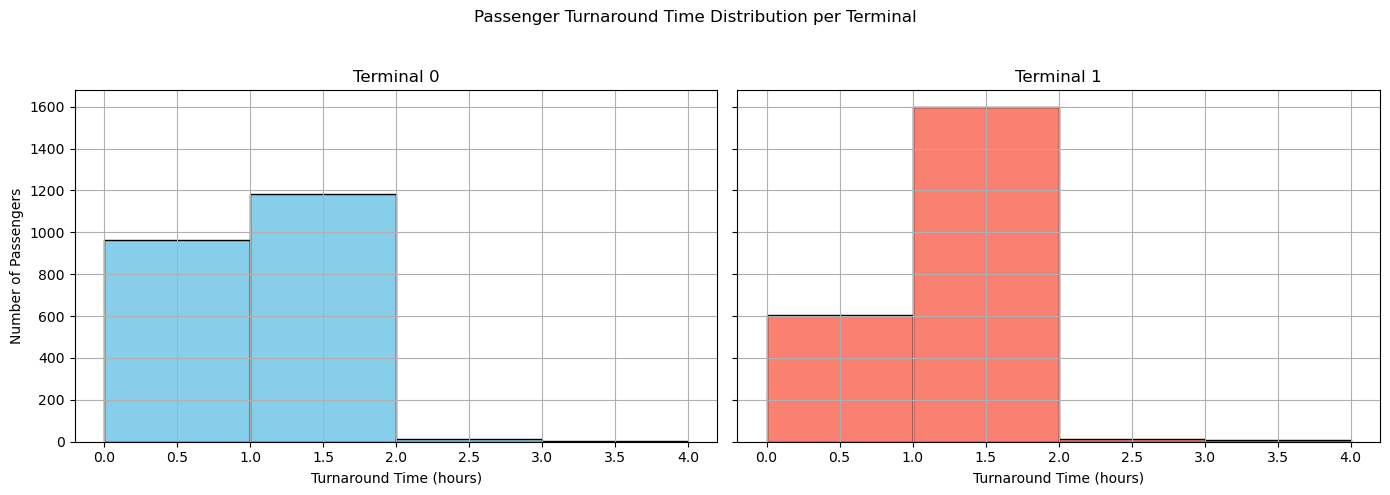

In [21]:

# Define bins (hourly intervals)
max_turnaround = max(terminal_0_df["turn_around_time"].max(), terminal_1_df["turn_around_time"].max())
bins = range(0, int(max_turnaround) + 2)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Terminal 0 histogram
axs[0].hist(terminal_0_df["turn_around_time"], bins=bins, color='skyblue', edgecolor='black')
axs[0].set_title("Terminal 0")
axs[0].set_xlabel("Turnaround Time (hours)")
axs[0].set_ylabel("Number of Passengers")
axs[0].grid(True)

# Terminal 1 histogram
axs[1].hist(terminal_1_df["turn_around_time"], bins=bins, color='salmon', edgecolor='black')
axs[1].set_title("Terminal 1")
axs[1].set_xlabel("Turnaround Time (hours)")
axs[1].grid(True)

plt.suptitle("Passenger Turnaround Time Distribution per Terminal")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

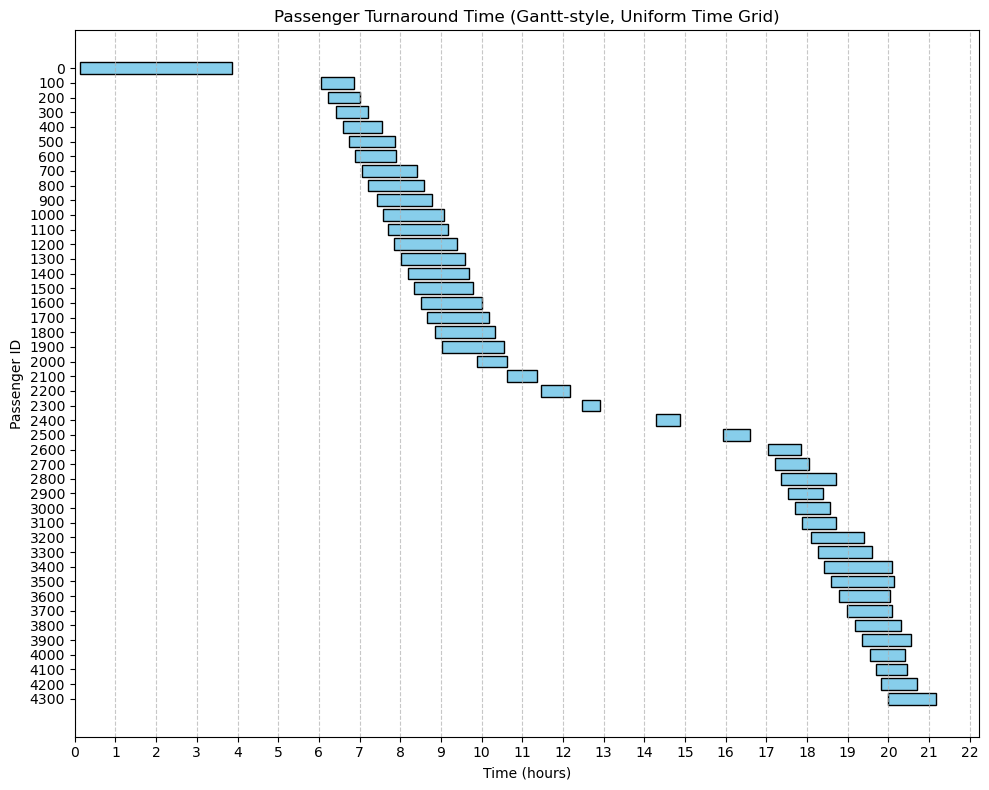

In [22]:

sample_df = passenger_df.iloc[::100].copy()

# Sample by index increments (e.g., every 100th row)
sample_df = passenger_df.iloc[::100].copy()

# Prepare data
starts = sample_df["terminal_arrival_time"]
durations = sample_df["turn_around_time"]
passenger_ids = sample_df["passenger_id"].astype(str)

# Set figure
plt.figure(figsize=(10, 8))
plt.barh(passenger_ids, durations, left=starts, color='skyblue', edgecolor='black')

# Set x-axis gridlines and ticks at every 1 hour
xmin = int(sample_df["terminal_arrival_time"].min())
xmax = int(sample_df["destination_arrival_time"].max()) + 1
plt.xticks(np.arange(xmin, xmax + 1, 1))  # every 1 hour
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Labels and layout
plt.xlabel("Time (hours)")
plt.ylabel("Passenger ID")
plt.title("Passenger Turnaround Time (Gantt-style, Uniform Time Grid)")
plt.tight_layout()
plt.gca().invert_yaxis()

plt.show()

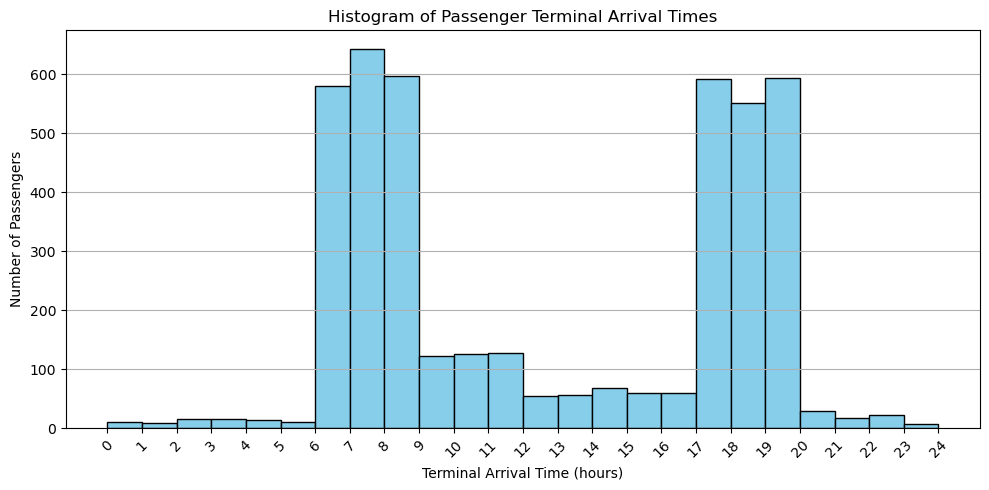

In [23]:
# Define bins: from min to max time, 1-hour step
min_time = int(passenger_df["terminal_arrival_time"].min())
max_time = int(passenger_df["terminal_arrival_time"].max()) + 1
bins = np.arange(min_time, max_time + 1, 1)  # 1-hour bins

# Plot
plt.figure(figsize=(10, 5))
plt.hist(passenger_df["terminal_arrival_time"], bins=bins, color='skyblue', edgecolor='black')

# Labels and styling
plt.xlabel("Terminal Arrival Time (hours)")
plt.ylabel("Number of Passengers")
plt.title("Histogram of Passenger Terminal Arrival Times")
plt.grid(True, axis='y')
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()